# Data Visualization

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
churn_data = pd.read_csv('Customer-Churn-Records.csv')

In [4]:
df = churn_data.copy()

In [5]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  object 
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  object 
 5   Gender              10000 non-null  object 
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card 

In [7]:
drop_feature = ['Surname', 'RowNumber', 'CustomerId']
df = df.drop(drop_feature, axis=1)

## ดูการกระจายตัวของแต่ละ Feature

In [8]:
numerical_col = df.select_dtypes(exclude='object').columns
categorical_col = df.select_dtypes(include='object').columns

In [106]:
df['Point Earned'].describe()

count    10000.000000
mean       606.515100
std        225.924839
min        119.000000
25%        410.000000
50%        605.000000
75%        801.000000
max       1000.000000
Name: Point Earned, dtype: float64

<Axes: ylabel='Point Earned'>

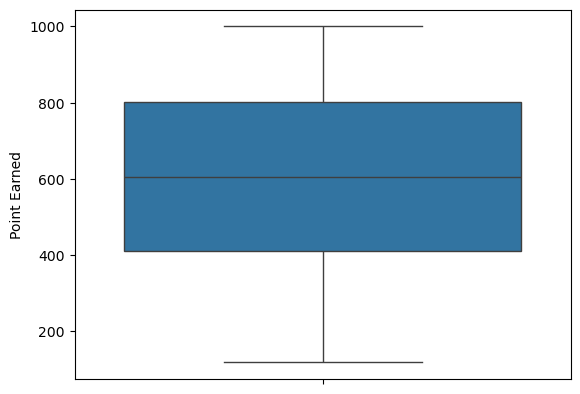

In [105]:
sns.boxplot(df['Point Earned'])

In [107]:
df['CreditScore'].describe()

count    10000.000000
mean       650.528800
std         96.653299
min        350.000000
25%        584.000000
50%        652.000000
75%        718.000000
max        850.000000
Name: CreditScore, dtype: float64

<Axes: ylabel='CreditScore'>

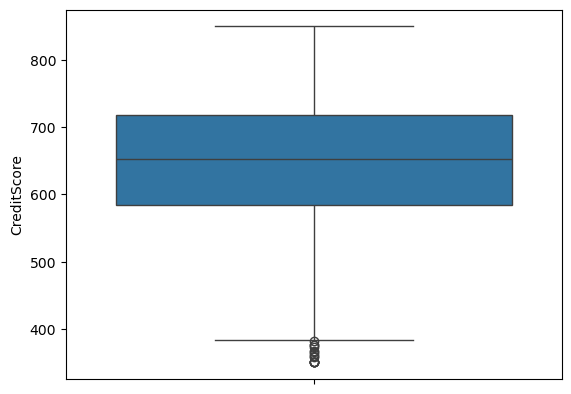

In [108]:
sns.boxplot(df['CreditScore'])

### Numerical Data

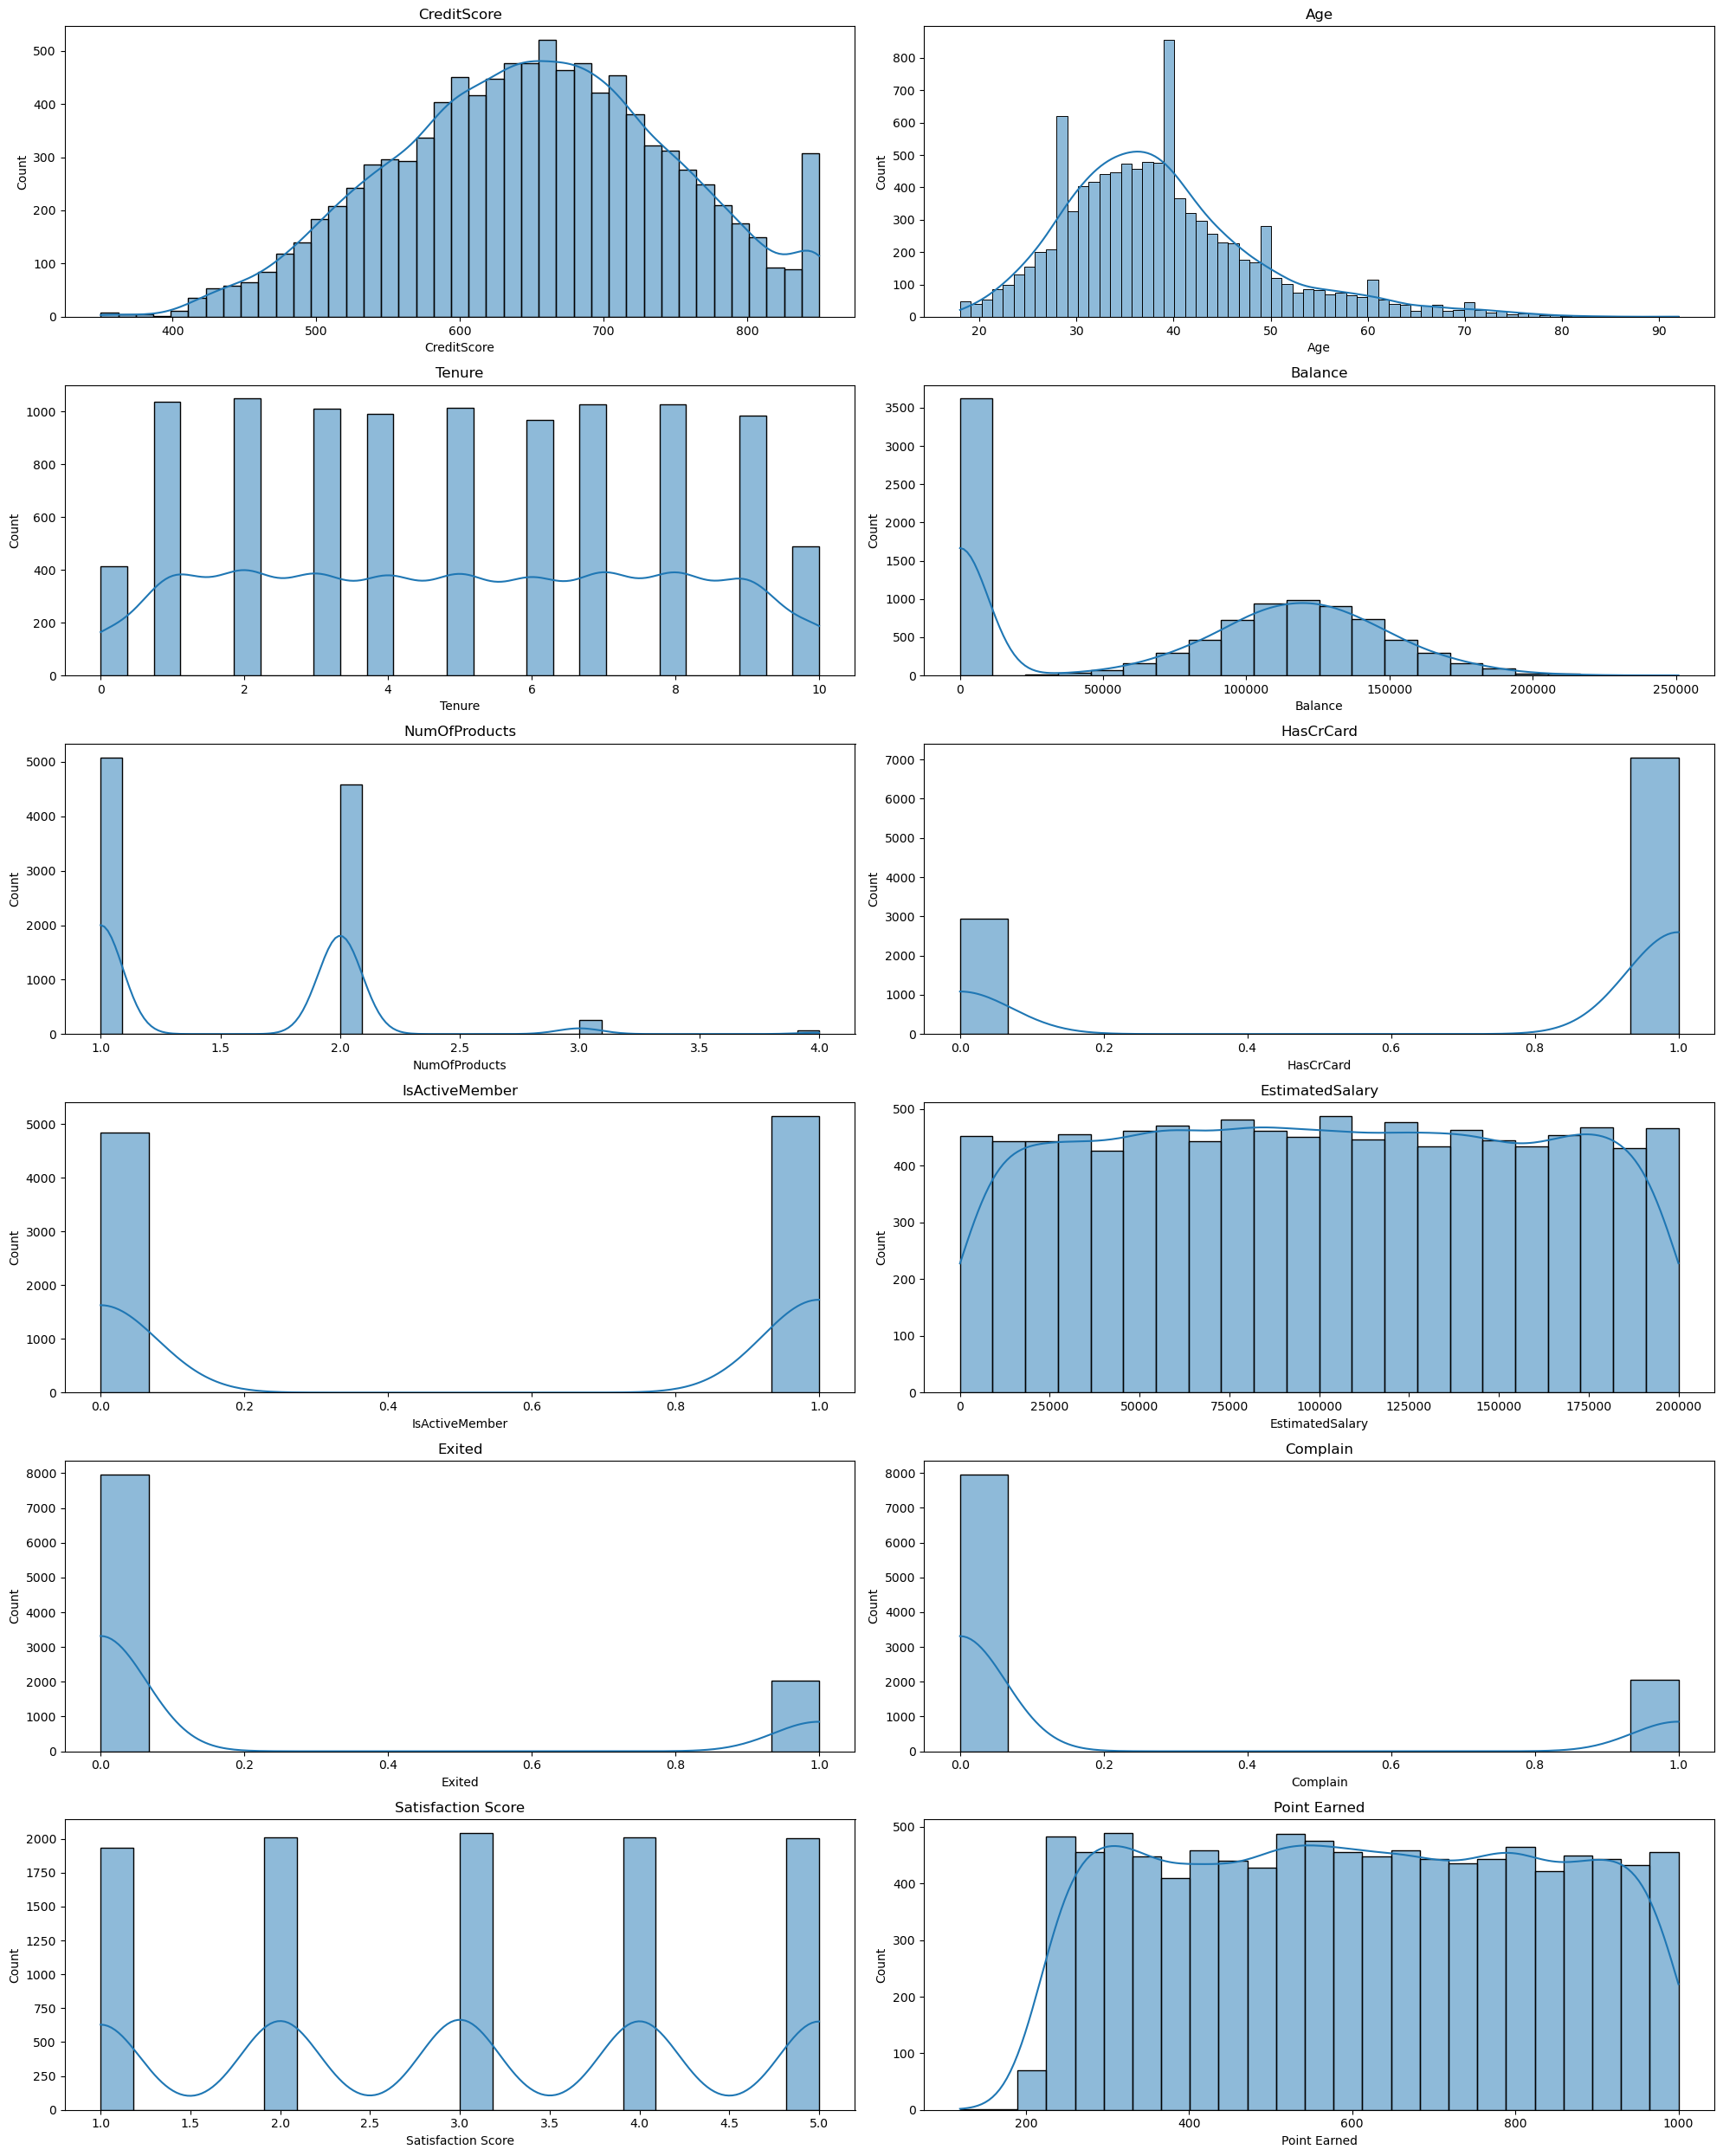

In [11]:
fig, axes = plt.subplots(nrows=6, 
                         ncols=2,
                         figsize=[20, 25])
for i, columns in enumerate(numerical_col):
    row, col = divmod(i, 2)
    sns.histplot(df[columns],
                 ax=axes[row, col],
                 kde=True)
    axes[row, col].set_title(columns)

plt.tight_layout()
plt.show()

### Categorical Data

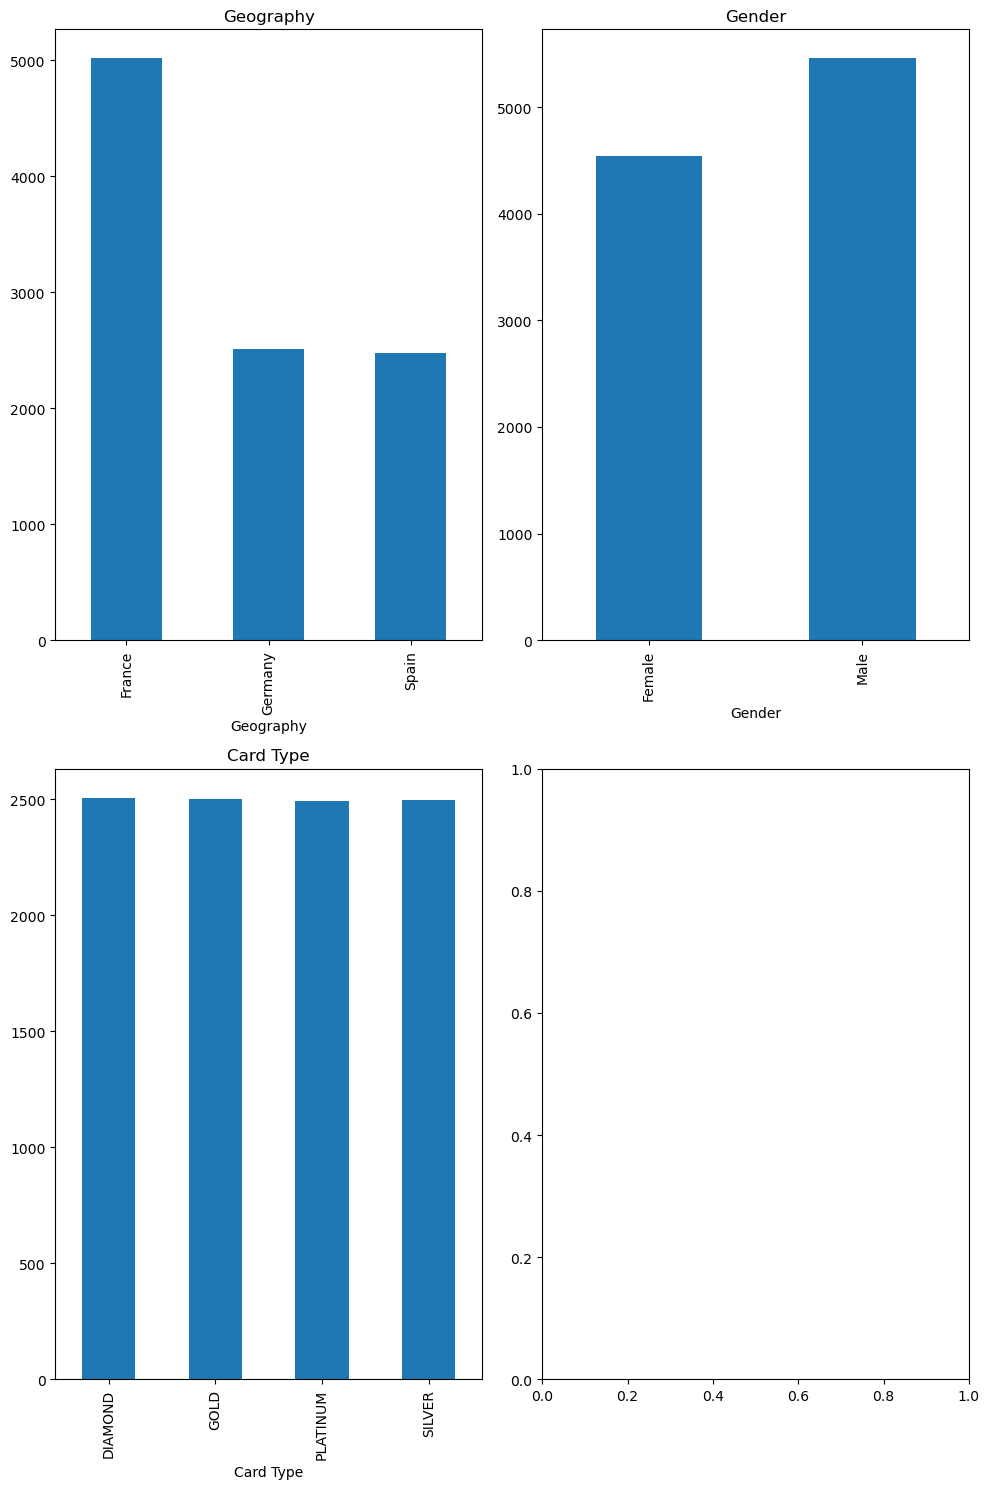

In [12]:
fig, axes = plt.subplots(nrows=2,
                        ncols=2,
                        figsize=[10 ,15])
for i, column in enumerate(categorical_col):
    row, col = divmod(i, 2)
    df.groupby(column)[column].value_counts().plot(kind='bar',
                                                   ax=axes[row, col])
    axes[row, col].set_title(column)
plt.tight_layout()
plt.show()

## Insight

### ดู correlation

In [71]:
corr = df.corr(numeric_only=True)

<Axes: >

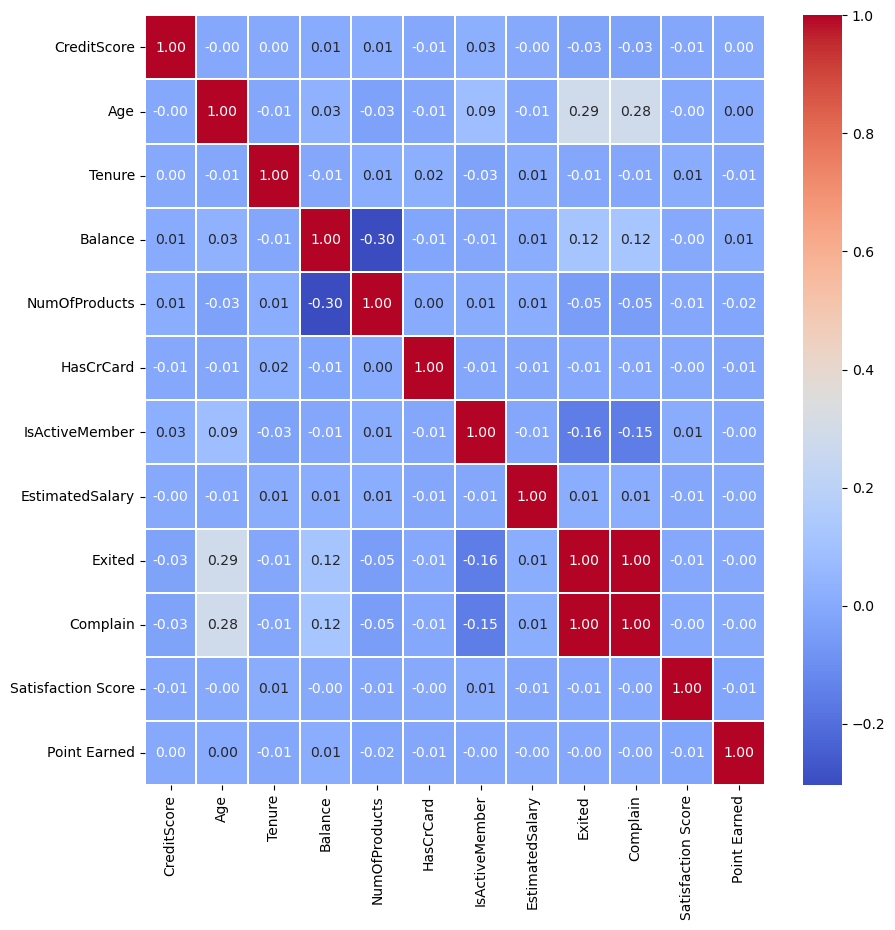

In [87]:
plt.figure(figsize=[10, 10])
sns.heatmap(corr, cmap='coolwarm', annot=True, fmt='.2f', lw=.3)

### 1. ดูช่วงอายุที่ ออก กับไม่ออก

In [13]:
df['Age'].describe()

count    10000.000000
mean        38.921800
std         10.487806
min         18.000000
25%         32.000000
50%         37.000000
75%         44.000000
max         92.000000
Name: Age, dtype: float64

In [14]:
bins = [0, 20, 40, 60, 80]  # กำหนดช่วง
labels = ['>=20', '21-40', '41-60', '<=60']  # ชื่อช่วง
df['Binned-Age'] = pd.cut(df['Age'],
                         bins=bins,
                         labels=labels,
                         right=True)

In [15]:
df[['Age', 'Binned-Age']].head()

,Age,Binned-Age
0,42,41-60
1,41,41-60
2,42,41-60
3,39,21-40
4,43,41-60


In [16]:
insight_1 = df.groupby(['Binned-Age'])['Exited'].value_counts().unstack()

In [17]:
insight_1

Exited,0,1
Binned-Age,,
>=20,84,5
21-40,5648,682
41-60,1881,1236
<=60,338,114


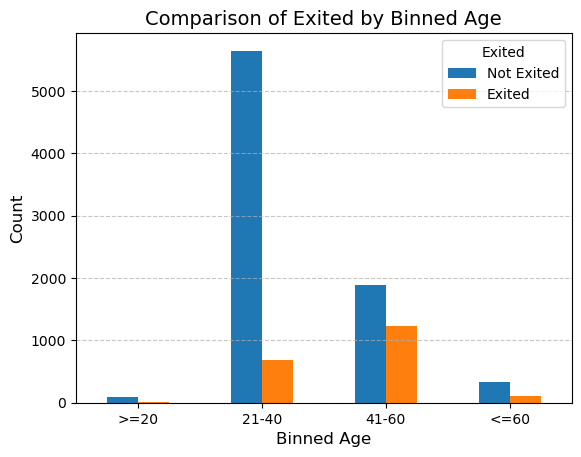

In [18]:
insight_1.plot(kind='bar')
plt.title("Comparison of Exited by Binned Age", fontsize=14)
plt.xlabel("Binned Age", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.legend(["Not Exited", "Exited"], title="Exited")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.7)

### 2. ดูจำนวน คนออก, ไม่ออก ในแต่ละ ประเทศ แยกชายหญิง

In [19]:
insight_2 = df.groupby(['Geography', 'Gender', 'Exited'])['Exited'].count().unstack()

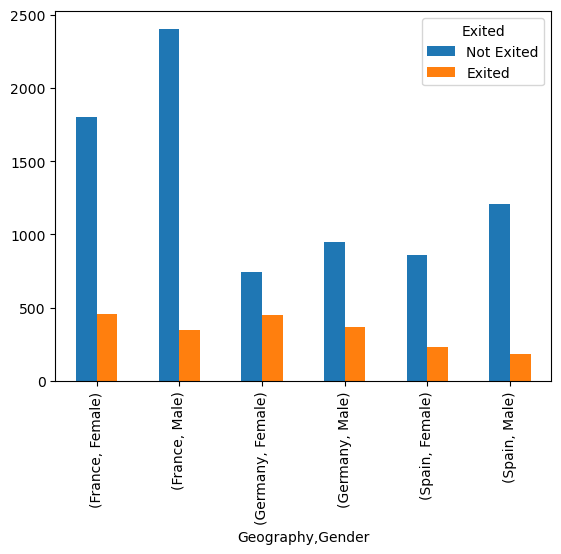

In [20]:
insight_2.plot(kind='bar')
plt.legend(["Not Exited", "Exited"], title="Exited")
plt.show()

### 3. อัตราคนออก กับไม่ออก

In [21]:
insight_3 = df['Exited'].value_counts()

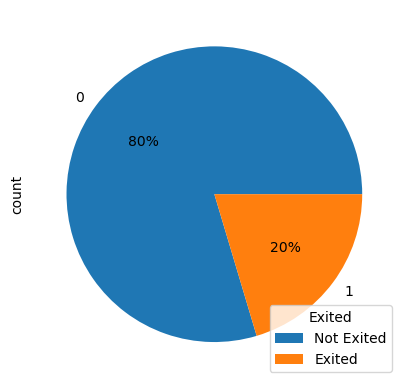

In [22]:
insight_3.plot(kind='pie', autopct='%1.0f%%')
plt.legend(["Not Exited", "Exited"], title="Exited", loc='best')


### 4. ดู ประเทศ กับ card type ว่ามีส่วนใดถือมากที่สุด และดูคนออก

In [23]:
df.columns

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary',
       'Exited', 'Complain', 'Satisfaction Score', 'Card Type', 'Point Earned',
       'Binned-Age'],
      dtype='object')

In [24]:
insight_4 = df.groupby(['Geography', 'Card Type', 'Exited'])['Exited'].count().unstack()

In [25]:
insight_4

Exited                  0    1
Geography Card Type           
France    DIAMOND    1009  221
          GOLD       1045  190
          PLATINUM   1070  194
          SILVER     1079  206
Germany   DIAMOND     428  220
          GOLD        452  201
          PLATINUM    403  205
          SILVER      412  188
Spain     DIAMOND     524  105
          GOLD        523   91
          PLATINUM    514  109
          SILVER      503  108

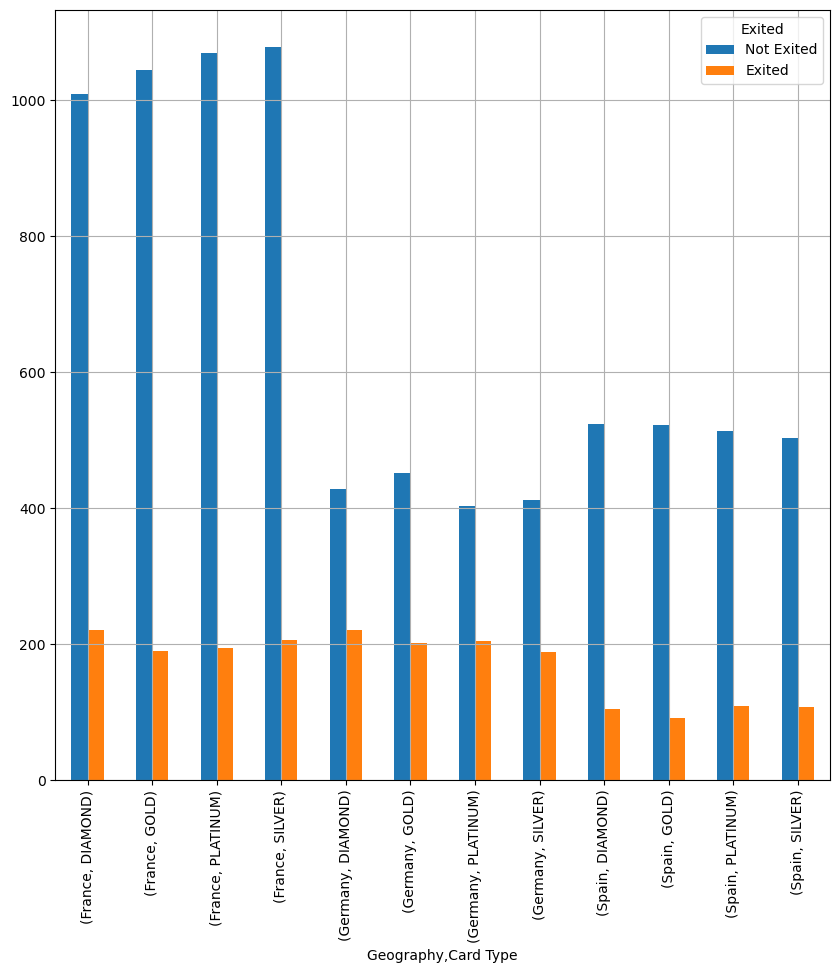

In [26]:
insight_4.plot(kind='bar',
               figsize=[10, 10],
               grid=True)
plt.legend(["Not Exited", "Exited"], title="Exited", loc='best')
plt.show()

### 5. ดู balance กับ NumOfProducts

In [30]:
insight_5 = df.groupby(['NumOfProducts'])['Balance'].mean()

In [44]:
df['NumOfProducts'].unique()

array([1, 3, 2, 4], dtype=int64)

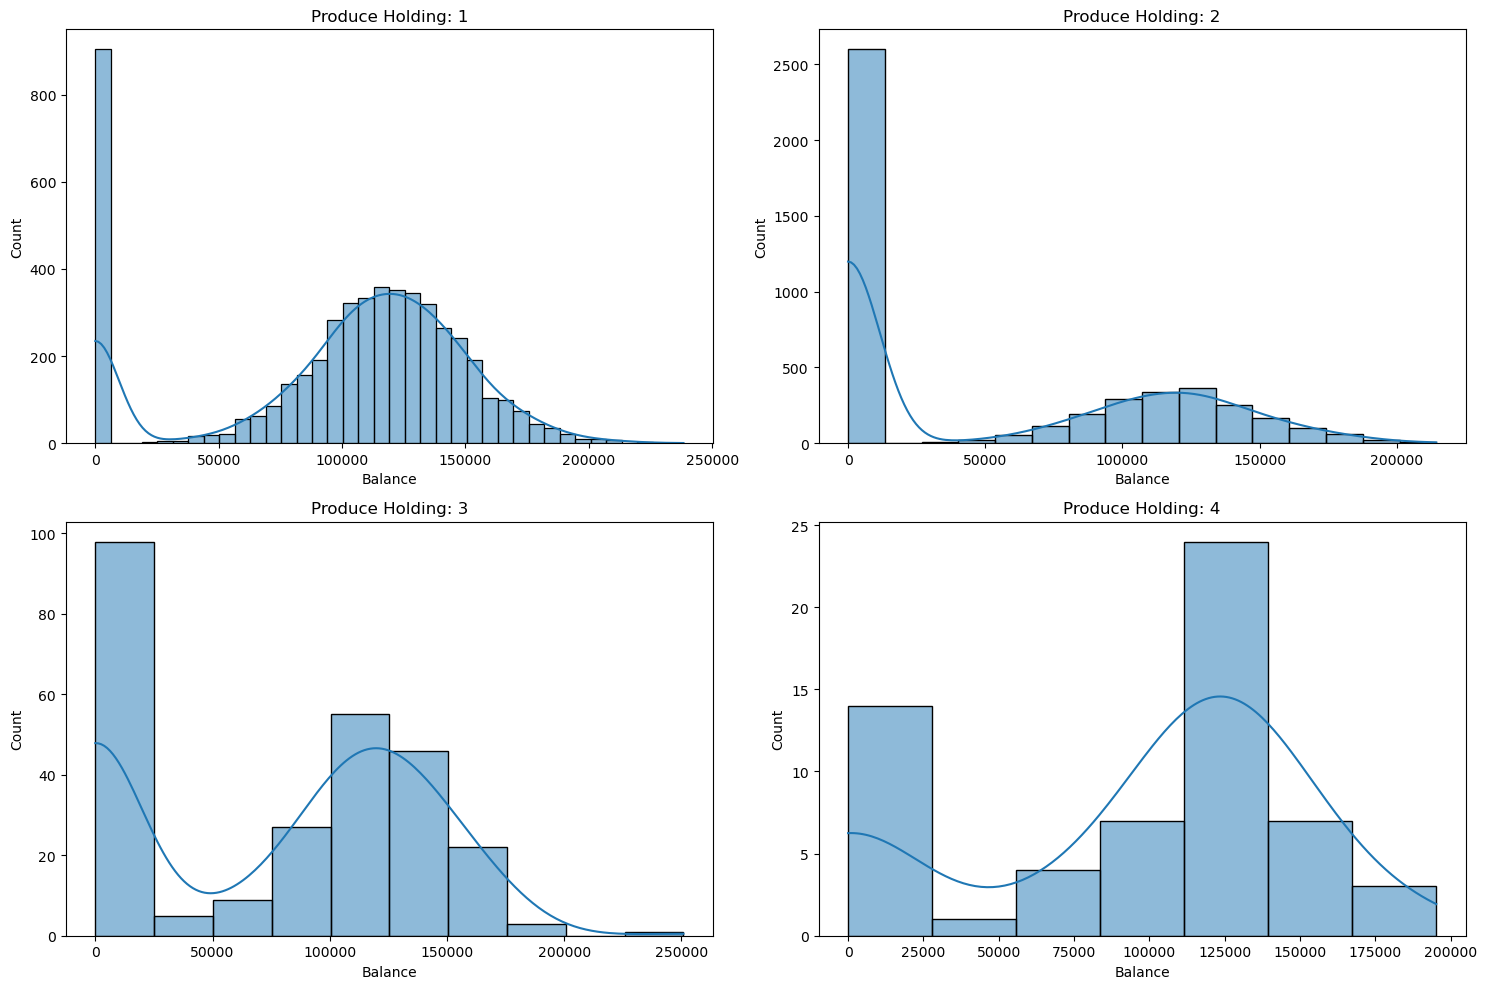

In [54]:
fig, axes = plt.subplots(nrows=2,
                         ncols=2,
                         figsize=[15, 10])
for i, column in zip(np.arange(0, 4), np.arange(0, 4)):
    row, col = divmod(i, 2)
    sns.histplot(df['Balance'][df['NumOfProducts'] == i+1],
                 ax=axes[row, col],
                 kde=True)
    axes[row, col].set_title(f'Produce Holding: {i+1}')
plt.tight_layout()
# plt.xticks(rotation=45)
plt.show()

array([1, 3, 2, 4], dtype=int64)

### 6. ดู Tenure เทียบกับ Exited

In [57]:
insight_6 = df.groupby(['Tenure', 'Exited'])['Exited'].value_counts().unstack()

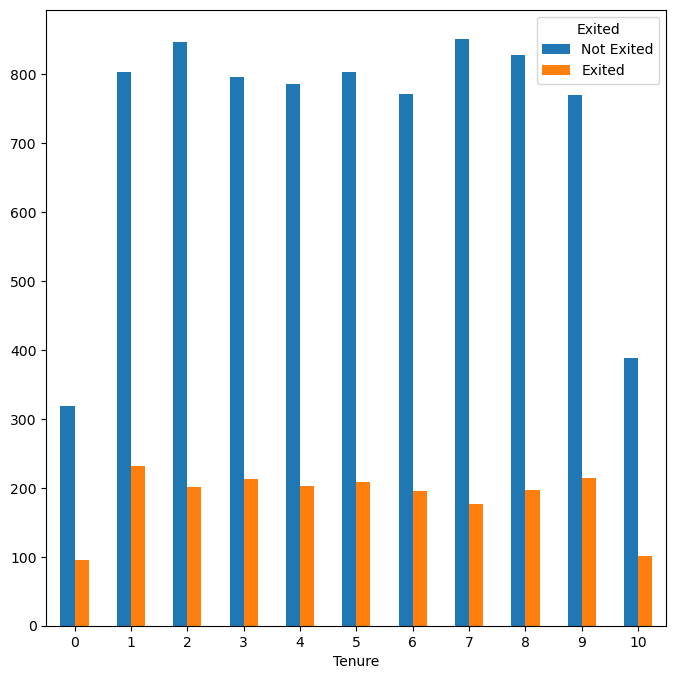

In [64]:
insight_6.plot(kind='bar',
               figsize=[8, 8])
plt.legend(["Not Exited", "Exited"], title="Exited")
plt.xticks(rotation=0)
plt.show()

### 7. ดูอัตราคนออก เทียบกับ Satisfaction Score

In [89]:
insight_8 = df.groupby(['Satisfaction Score', 'Exited'])['Exited'].count().unstack()

In [104]:
insight_8

Exited,0,1
Satisfaction Score,,
1,1545,387
2,1575,439
3,1641,401
4,1594,414
5,1607,397


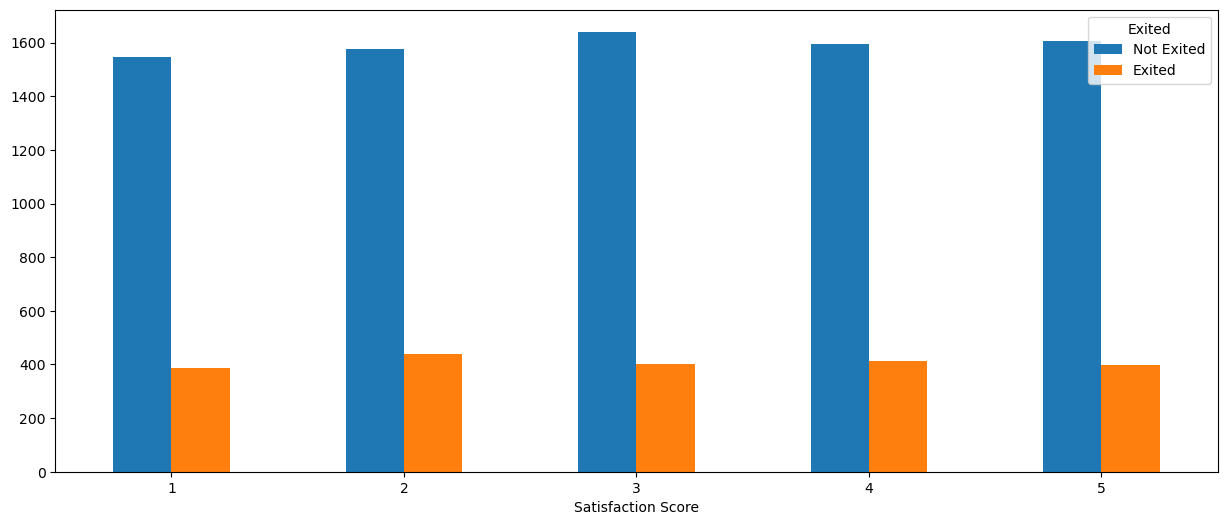

In [103]:
insight_8.plot(kind='bar',
              figsize=[15, 6])
plt.legend(["Not Exited", "Exited"], title="Exited")
plt.xticks(rotation=0)
plt.show()

### 8. ดู Balance เทียบกับ ประเภทบัตร

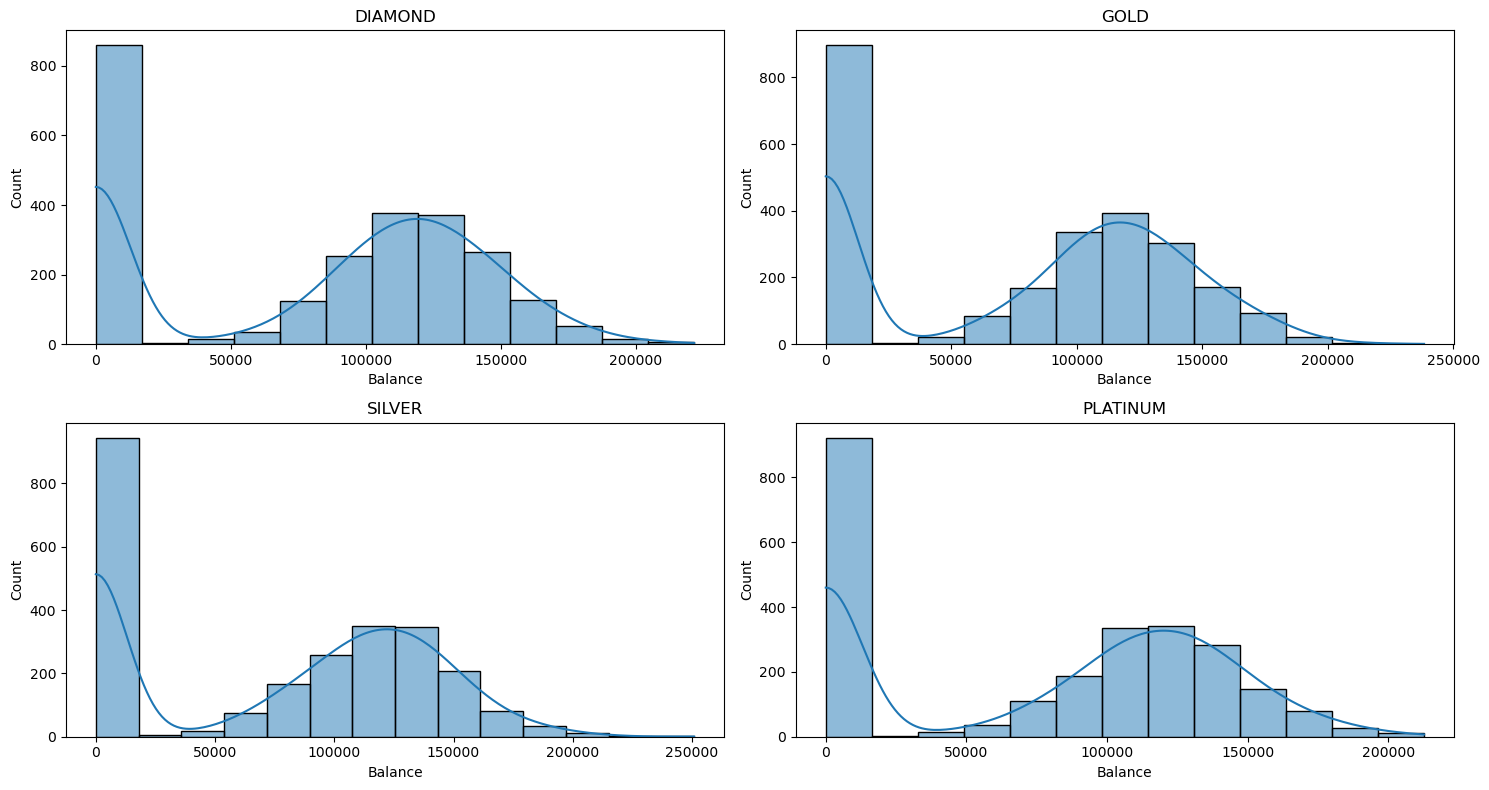

In [112]:
fig, axes = plt.subplots(nrows=2,
                         ncols=2,
                         figsize=[15, 8])
for i, column in enumerate(df['Card Type'].unique()):
    row, col = divmod(i, 2)
    sns.histplot(df['Balance'][df['Card Type'] == column],
                 ax=axes[row, col],
                 kde=True)
    axes[row, col].set_title(f'{column}')
plt.tight_layout()
# plt.xticks(rotation=45)
plt.show()

### 9. ดูเงินเดือน เทียบกับ ประเภทการ์ด

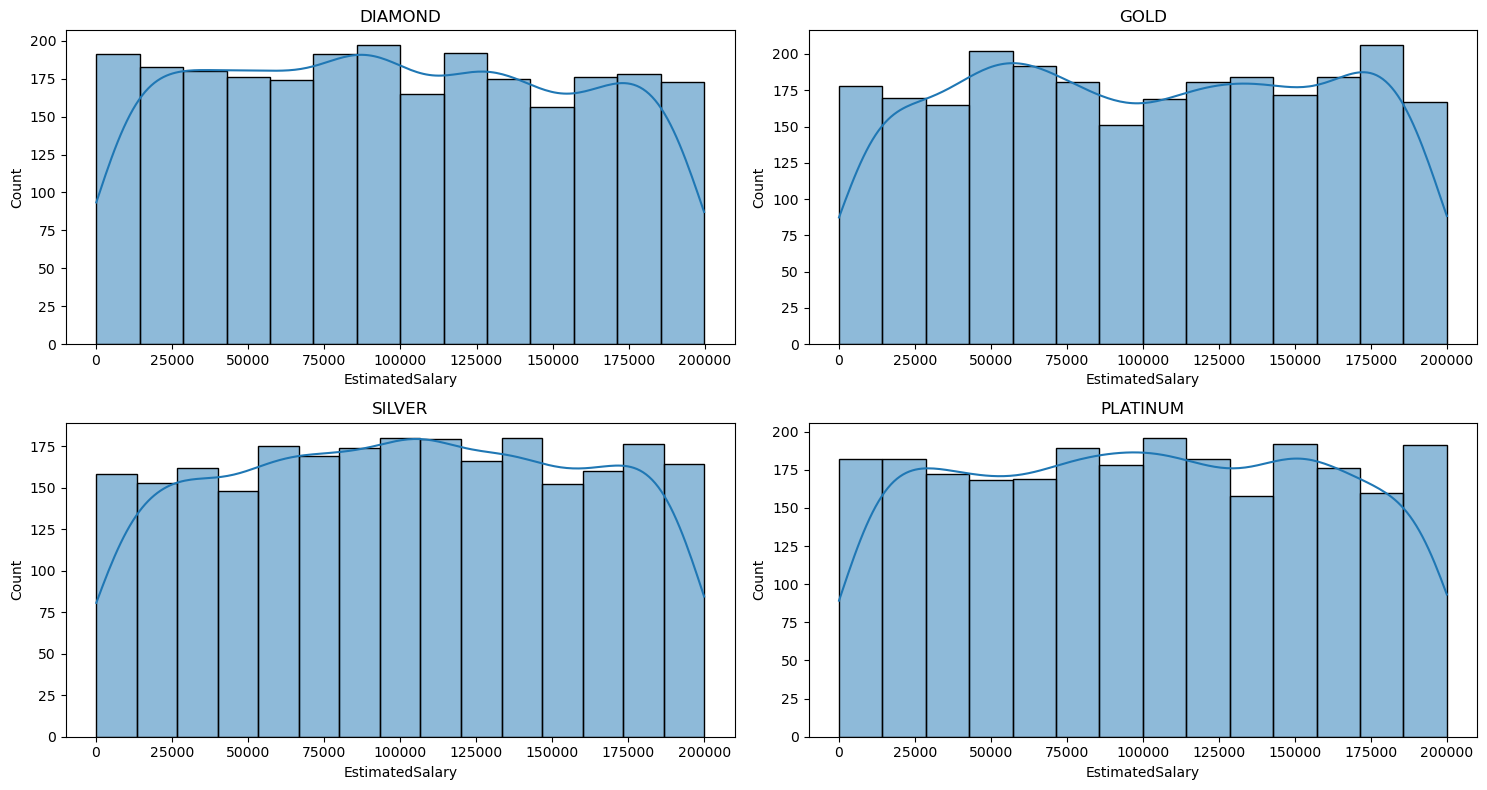

In [113]:
fig, axes = plt.subplots(nrows=2,
                         ncols=2,
                         figsize=[15, 8])
for i, column in enumerate(df['Card Type'].unique()):
    row, col = divmod(i, 2)
    sns.histplot(df['EstimatedSalary'][df['Card Type'] == column],
                 ax=axes[row, col],
                 kde=True)
    axes[row, col].set_title(f'{column}')
plt.tight_layout()
# plt.xticks(rotation=45)
plt.show()

### 10. ดู CreditScore เทียบกับ ประเภทการ์ด

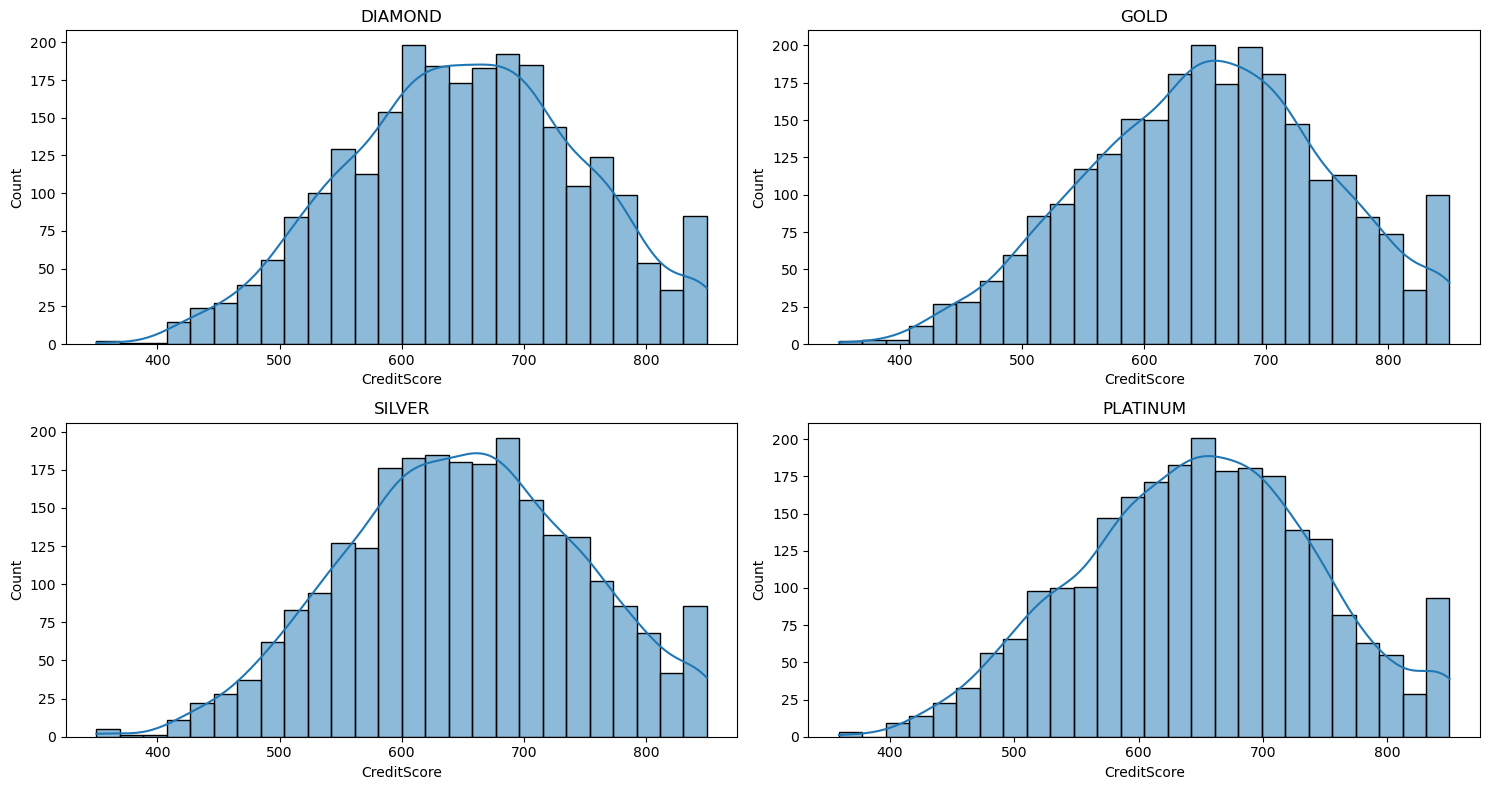

In [114]:
fig, axes = plt.subplots(nrows=2,
                         ncols=2,
                         figsize=[15, 8])
for i, column in enumerate(df['Card Type'].unique()):
    row, col = divmod(i, 2)
    sns.histplot(df['CreditScore'][df['Card Type'] == column],
                 ax=axes[row, col],
                 kde=True)
    axes[row, col].set_title(f'{column}')
plt.tight_layout()
# plt.xticks(rotation=45)
plt.show()